In [1]:
import numpy as np
import pandas as pd
from rdkit import Chem
from rdkit.Chem import AllChem, Draw, rdDetermineBonds
from rdkit.Chem.Draw import IPythonConsole
IPythonConsole.ipython_3d = True
import py3Dmol

In [2]:
# fmt: off
atom_symbols = {
    1: "H", 2: "He", 3: "Li", 4: "Be", 5: "B", 6: "C", 7: "N", 8: "O", 9: "F", 10: "Ne",
    11: "Na", 12: "Mg", 13: "Al", 14: "Si", 15: "P", 16: "S", 17: "Cl", 18: "Ar",
    19: "K", 20: "Ca", 21: "Sc", 22: "Ti", 23: "V", 24: "Cr", 25: "Mn", 26: "Fe",
    27: "Co", 28: "Ni", 29: "Cu", 30: "Zn"
}
# fmt: on

In [3]:
def create_xyz_block(symbols, coordinates):
    """
    Args:
        symbols (list): List of atomic symbols e.g., ['C', 'H', 'H', 'H', 'H']
        coordinates (np.array): N x 3 array of Cartesian coordinates
    
    Returns:
        str: A formatted XYZ block string
    """
    n_atoms = len(symbols)
    lines = [str(n_atoms), "Generated by Python"]
    
    # Body: Symbol and coordinates
    for z, coord in zip(symbols, coordinates):
        label = atom_symbols.get(z)
        x, y, z = coord
        lines.append(f"{label:2s} {x:12.6f} {y:12.6f} {z:12.6f}")
    
    return "\n".join(lines)

In [4]:
def xyz_to_graph(Z, coords, charge=0, check_mol=False):
    mol = Chem.MolFromXYZBlock(create_xyz_block(Z, coords))
    mol = Chem.Mol(mol)

    # print("total charge of molecule:", Chem.GetFormalCharge(mol))
    Chem.SanitizeMol(mol)
    # Chem.SanitizeMol(mol, sanitizeOps=Chem.SanitizeFlags.SANITIZE_ALL ^ Chem.SanitizeFlags.SANITIZE_PROPERTIES)
    
    mol.UpdatePropertyCache(strict=False)  

    rdDetermineBonds.DetermineConnectivity(mol)
    try:
        rdDetermineBonds.DetermineBondOrders(mol, charge)
    except ValueError:
        pass

    # rdDetermineBonds.DetermineBonds(mol, charge=charge)

    if check_mol:
        mol.UpdatePropertyCache()

    return mol

In [5]:
def draw_with_spheres(mol):
    v = py3Dmol.view(width=400, height=400)
    IPythonConsole.addMolToView(mol, v)
    v.zoomTo()
    v.setStyle({'sphere':{'scale':0.3}, 'stick':{'radius':0.2}})
    v.show()

In [32]:
csv_path = "data/AQM-sample-2.csv"
# csv_path = "/home/cds/rketkaew/project-ml-strc-solv/ml-strc-solv/AQM_dataset.csv"

df = pd.read_csv(csv_path)
df["atomic_numbers"] = df["atomic_numbers"].apply(eval)
df["gas_xyz"] = df["gas_xyz"].apply(eval)
# df["sol_xyz"] = df["sol_xyz"].apply(eval)
samples = df.to_dict(orient="records")

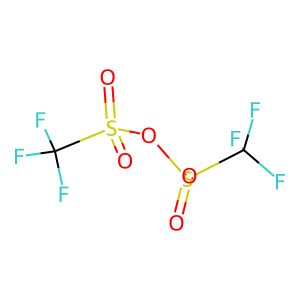

In [47]:
row = samples[112]
Z = np.array(row["atomic_numbers"])
gas_xyz = np.array(row["gas_xyz"]).reshape(-1, 3)
mol = xyz_to_graph(Z, gas_xyz, charge=0)
Draw.MolToImage(mol)

In [18]:
# get valence
for atom in mol.GetAtoms():
    print("Processing atom ", str(atom.GetIdx()), atom.GetSymbol(), atom.GetDegree(), atom.GetTotalValence(), atom.GetFormalCharge())
    # print(atom.GetSymbol(), atom.GetDegree())

Processing atom  0 N 3 3 0
Processing atom  1 C 3 4 0
Processing atom  2 C 3 4 0
Processing atom  3 C 3 4 0
Processing atom  4 N 3 3 0
Processing atom  5 O 1 1 -1
Processing atom  6 O 1 1 -1
Processing atom  7 C 3 4 1
Processing atom  8 C 3 4 0
Processing atom  9 N 3 3 0
Processing atom  10 O 1 1 -1
Processing atom  11 O 1 1 -1
Processing atom  12 C 3 4 1
Processing atom  13 H 1 1 0
Processing atom  14 H 1 1 0
Processing atom  15 H 1 1 0
Processing atom  16 H 1 1 0
Processing atom  17 H 1 1 0


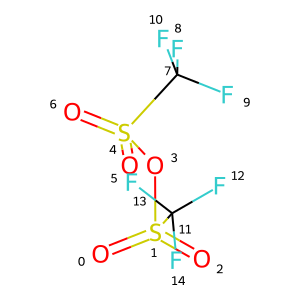

In [42]:
mol2d = Chem.Mol(mol)
# AllChem.Compute2DCoords(mol2d)
dos = Draw.MolDrawOptions()
dos.addAtomIndices=True
Draw.MolToImage(mol2d, options=dos, size=(300, 300))

In [20]:
draw_with_spheres(mol)

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

### Process over all molecules in AQS dataset

In [33]:
%%capture --no-stdout

# Create mol and collect stats (successful, failure)
total = len(samples)
success = 0
fail = 0
fail_mol_ids = []
fail_mol_names = []

for idx in range(total):
    row = samples[idx]
    Z = np.array(row["atomic_numbers"])
    gas_xyz = np.array(row["gas_xyz"]).reshape(-1, 3)
    try:
        mol = xyz_to_graph(Z, gas_xyz, charge=0, check_mol=True)
        success += 1
    except:
        fail_mol_ids.append(row["molecule_id"])
        fail_mol_names.append(row["gas_conformation"])
        fail += 1
    Draw.MolToImage(mol)

print(f"Total: {total}, Success: {success}, Fail: {fail}")

Total: 2063, Success: 2035, Fail: 28


In [34]:
fail_mol_ids

[172,
 172,
 172,
 184,
 184,
 184,
 184,
 184,
 184,
 184,
 184,
 184,
 205,
 205,
 207,
 207,
 207,
 207,
 275,
 275,
 275,
 275,
 275,
 275,
 275,
 275,
 275,
 275]

In [35]:
fail_mol_names

['Geom-m172-c5',
 'Geom-m172-c6',
 'Geom-m172-c7',
 'Geom-m184-c10',
 'Geom-m184-c12',
 'Geom-m184-c13',
 'Geom-m184-c14',
 'Geom-m184-c15',
 'Geom-m184-c16',
 'Geom-m184-c17',
 'Geom-m184-c18',
 'Geom-m184-c19',
 'Geom-m205-c6',
 'Geom-m205-c7',
 'Geom-m207-c3',
 'Geom-m207-c4',
 'Geom-m207-c5',
 'Geom-m207-c6',
 'Geom-m275-c1',
 'Geom-m275-c11',
 'Geom-m275-c2',
 'Geom-m275-c20',
 'Geom-m275-c22',
 'Geom-m275-c23',
 'Geom-m275-c24',
 'Geom-m275-c27',
 'Geom-m275-c3',
 'Geom-m275-c4']